In [1]:
!pip install mpi4py


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mpi4py: filename=mpi4py-3.1.5-cp310-cp310-linux_x86_64.whl size=2746528 sha256=da02ebd52d03cc061117f613b74ddf50d5725213264c7c630f929a472a6fa58e
  Stored in directory: /root/.cache/pip/wheels/18/2b/7f/c852523089e9182b45fca50ff56f49a51eeb6284fd25a66713
Successfully built mpi4py


In [7]:
%%writefile integral.py
import numpy as np
from mpi4py import MPI
import time

t_start = time.time()

comm = MPI.COMM_WORLD

rank = comm.Get_rank()
size = comm.Get_size()

n = 10000000

X = np.linspace(1,10,n)

rank_n = n // size


if rank == size - 1:
    start, end = rank * rank_n, n

else:
    start, end = rank * rank_n, (rank + 1) * rank_n

x = X[start:end]
y = x**2
int_local = np.trapz(y, x = x)

int_sum = None
if rank == 0:
    int_sum = np.zeros(1)

comm.Reduce(int_local, int_sum, op=MPI.SUM, root=0)

if rank == 0:
    t_end = time.time()
    dt = t_end - t_start
    with open('results.csv', 'a+') as f:
       f.write(f'{int_sum[0]}, {dt}\n')


Overwriting integral.py


In [8]:
for i in range(1,5):
  !mpirun -n $i --allow-run-as-root --oversubscribe python integral.py

Text(0, 0.5, 'Error')

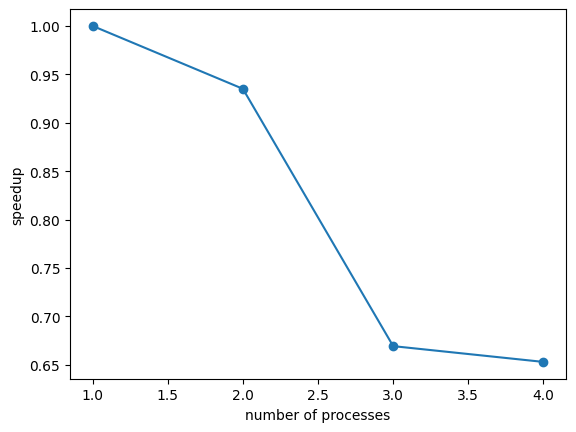

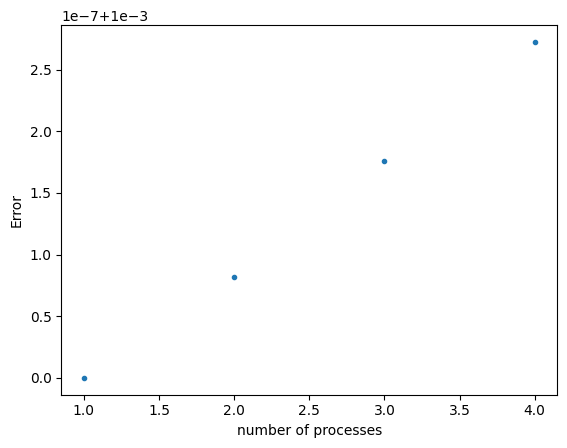

In [10]:
import numpy as np
import matplotlib.pyplot as plt


data = np.array([])
time = np.array([])

with open('results.csv') as f:
    for line in f:
        data, time = np.append(data, float(line.split(',')[0])), np.append(time, float(line.split(',')[1]))

plt.plot(np.arange(1, 5, 1),time[0] / time , '-o')
plt.xlabel('number of processes')
plt.ylabel('speedup')

I_true = 10**3/3
plt.figure()
plt.plot(np.arange(1, 5, 1), abs(data - I_true)/I_true, '.')
plt.xlabel('number of processes')
plt.ylabel('Error')

I used google.colab, so it is impossible to gain the speedup over 1.5.